# Backtest Results

In [1]:
import ast
import csv
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Configuration ---
SYMBOLS = ["AAPL", "MSFT"]
CSV_PATHS = {s: f"data/{s}.csv" for s in SYMBOLS}
INITIAL_CAPITAL = 10_000.0

# --- Load equity curve ---
with open("results/equity_curve.csv") as f:
    fills = list(csv.DictReader(f))

fill_dates  = [datetime.fromisoformat(r["timestamp"]) for r in fills]
equity      = [float(r["equity"]) for r in fills]
cash        = [float(r["cash"]) for r in fills]
market_val  = [float(r["market_value"]) for r in fills]
holdings    = [ast.literal_eval(r["holdings"]) for r in fills]  # dict per fill

# --- Load price data per symbol ---
symbol_bars: dict[str, tuple[list, list]] = {}
for symbol, path in CSV_PATHS.items():
    with open(path) as f:
        bars = list(csv.DictReader(f))
    symbol_bars[symbol] = (
        [datetime.strptime(r["timestamp"], "%Y-%m-%d") for r in bars],
        [float(r["close"]) for r in bars],
    )

# Use first symbol for date-range display
bar_dates = symbol_bars[SYMBOLS[0]][0]

print(f"Fills recorded : {len(fills)}")
for sym in SYMBOLS:
    dates, _ = symbol_bars[sym]
    print(f"Price bars ({sym:4s}): {len(dates)}  ({dates[0].date()} → {dates[-1].date()})")


## 1. Equity Curve

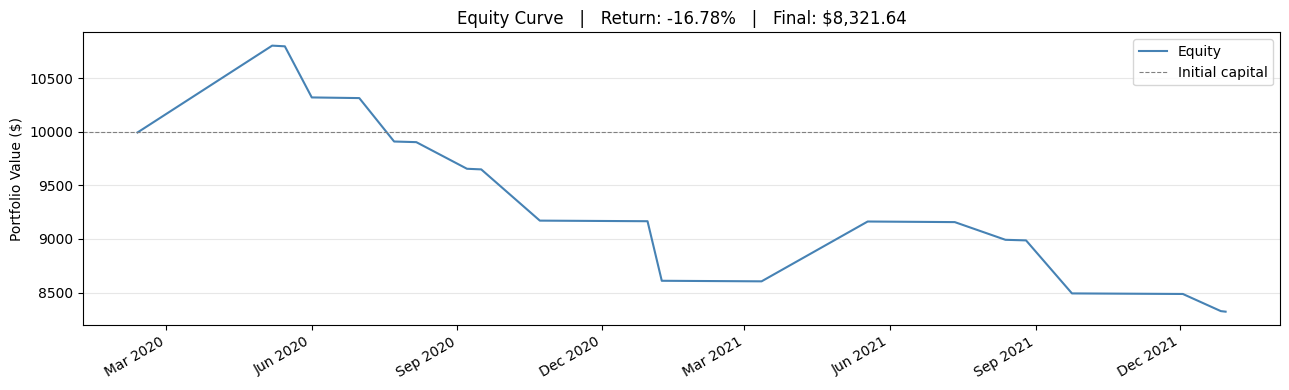

In [2]:
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(fill_dates, equity, color="steelblue", linewidth=1.5, label="Equity")
ax.axhline(INITIAL_CAPITAL, color="gray", linewidth=0.8, linestyle="--", label="Initial capital")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

final  = equity[-1]
ret_pct = (final / INITIAL_CAPITAL - 1) * 100
ax.set_title(f"Equity Curve   |   Return: {ret_pct:+.2f}%   |   Final: ${final:,.2f}")
ax.set_ylabel("Portfolio Value ($)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/equity_curve.png", dpi=150)
plt.show()

## 2. Drawdown

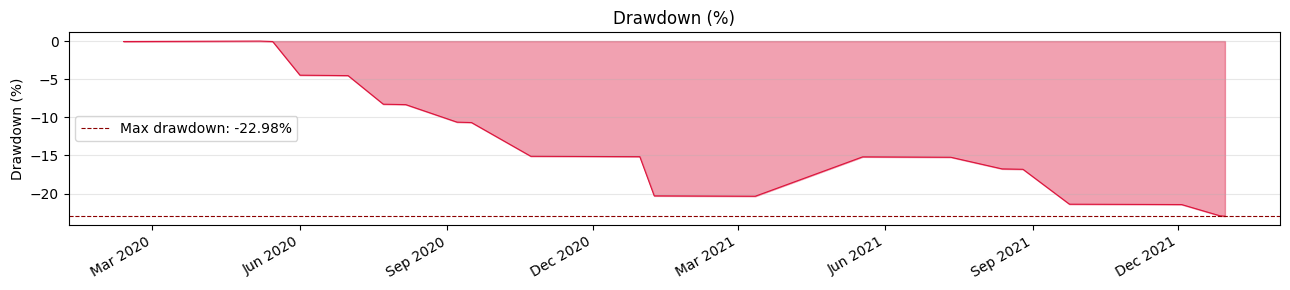

In [3]:
peak = INITIAL_CAPITAL
drawdown = []
for e in equity:
    peak = max(peak, e)
    drawdown.append((e - peak) / peak * 100)

max_dd = min(drawdown)

fig, ax = plt.subplots(figsize=(13, 3))

ax.fill_between(fill_dates, drawdown, 0, color="crimson", alpha=0.4)
ax.plot(fill_dates, drawdown, color="crimson", linewidth=0.8)
ax.axhline(max_dd, color="darkred", linewidth=0.8, linestyle="--", label=f"Max drawdown: {max_dd:.2f}%")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

ax.set_title("Drawdown (%)")
ax.set_ylabel("Drawdown (%)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/drawdown.png", dpi=150)
plt.show()

## 3. Price Chart with Trade Markers

In [4]:
COLORS = ["steelblue", "darkorange", "green", "purple", "brown"]

fig, ax = plt.subplots(figsize=(13, 5))

total_buys = 0
total_sells = 0

for idx, symbol in enumerate(SYMBOLS):
    color = COLORS[idx % len(COLORS)]
    sym_dates, sym_closes = symbol_bars[symbol]
    ax.plot(sym_dates, sym_closes, color=color, linewidth=1, label=f"{symbol} close")

    price_by_date = {d: c for d, c in zip(sym_dates, sym_closes)}
    buy_dates,  buy_prices  = [], []
    sell_dates, sell_prices = [], []

    for i, (d, h) in enumerate(zip(fill_dates, holdings)):
        prev_h = holdings[i - 1] if i > 0 else {}
        cur_qty  = h.get(symbol, 0)
        prev_qty = prev_h.get(symbol, 0) if isinstance(prev_h, dict) else 0
        price = price_by_date.get(d)
        if price is None:
            continue
        if prev_qty == 0 and cur_qty > 0:
            buy_dates.append(d)
            buy_prices.append(price)
        elif prev_qty > 0 and cur_qty == 0:
            sell_dates.append(d)
            sell_prices.append(price)

    ax.scatter(buy_dates,  buy_prices,  marker="^", color="green", s=80, zorder=5,
               label=f"{symbol} buy" if buy_dates else None)
    ax.scatter(sell_dates, sell_prices, marker="v", color="red",   s=80, zorder=5,
               label=f"{symbol} sell" if sell_dates else None)
    total_buys  += len(buy_dates)
    total_sells += len(sell_dates)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

ax.set_title(f"Price Chart with Trade Markers   |   {total_buys} buys, {total_sells} sells")
ax.set_ylabel("Price ($)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/trades.png", dpi=150)
plt.show()


## 4. Summary Statistics

In [5]:
num_days   = (bar_dates[-1] - bar_dates[0]).days
years      = num_days / 365.25
cagr       = ((equity[-1] / INITIAL_CAPITAL) ** (1 / years) - 1) * 100

# Per-fill returns for a rough Sharpe estimate (not annualised properly — POC only)
fill_returns = [(equity[i] - equity[i-1]) / equity[i-1] for i in range(1, len(equity))]
if len(fill_returns) > 1:
    avg_r  = sum(fill_returns) / len(fill_returns)
    std_r  = (sum((r - avg_r) ** 2 for r in fill_returns) / len(fill_returns)) ** 0.5
    sharpe = (avg_r / std_r) if std_r else float("nan")
else:
    sharpe = float("nan")

print("=" * 38)
print(f"  Initial capital  : ${INITIAL_CAPITAL:>10,.2f}")
print(f"  Final equity     : ${equity[-1]:>10,.2f}")
print(f"  Total return     : {(equity[-1]/INITIAL_CAPITAL - 1)*100:>+10.2f}%")
print(f"  CAGR             : {cagr:>+10.2f}%")
print(f"  Max drawdown     : {max_dd:>+10.2f}%")
print(f"  Sharpe (fills)   : {sharpe:>10.3f}")
print(f"  Number of fills  : {len(fills):>10}")
print(f"  Buys / Sells     : {total_buys:>5} / {total_sells:<5}")
print("=" * 38)
